In [22]:
# Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns           

# Confirming imports being successful
print ("Libraries imported successfully")

Libraries imported successfully


#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# Loading dataset from data folder
df = pd. read_csv (r"../data/retail_sales_data.csv")   # 👉 needed to use ../ at beginning although copied path where, .. means go one folder back

# Confirming dataset loaded successfully
print ("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
# Viewing first 5 rows of dataset
df. head ()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------

# Understanding Dataset Structure

In [4]:
# Shape (i.e.number of rows & columns)
print ("-" * 100)
print ("Shape of dataset:", df.shape)

# Column names
print ("-" * 100)
print ("Columns in dataset:")
print (df.columns)

# Data types + missing values
print ("-" * 100)
print ("Dataset Info:")
df. info ()

# Statistical summary
print ("-" * 100)
print ("Statistical Summary:")
df. describe ()

----------------------------------------------------------------------------------------------------
Shape of dataset: (9800, 18)
----------------------------------------------------------------------------------------------------
Columns in dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')
----------------------------------------------------------------------------------------------------
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-nu

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------

# Data Cleaning

In [5]:
# Checking missing values(if any)
print ("Missing values in each column are shown below:")
print (df. isnull(). sum())

# Viewing total missing values
print ("-" * 100)
print ("Total missing values:", df. isnull(). sum(). sum())

Missing values in each column are shown below:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
----------------------------------------------------------------------------------------------------
Total missing values: 11


### Observation: found all of those 11 missing values are from Postal Code column. 

In [6]:
# Fill missing values of Postal Code column with 0 value
df ['Postal Code'] = df ['Postal Code']. fillna(0). astype(int)

# Confirming missing values are handled successfully
print("Missing values handled")

# Re-Checking if there is any missing values
print ("-" * 100)
print ("Missing values in each column are shown below:")
print (df. isnull(). sum())

Missing values handled
----------------------------------------------------------------------------------------------------
Missing values in each column are shown below:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


### Why we filled Postal Code column missing values with 0?
- The column Postal Code = location identifier. It is not used for calculations (like sales, profit, etc.)
- Due to this it doesn't make sense to use mean/median and also we didn't drop this rows as we don't want to lose valid sales data
- Therefore, the best option is to fill those missing areas with placeholders like 0 or "unknown" if a column is not important for analysis.

In [7]:
# Checking if there is any duplicate rows
duplicates = df. duplicated(). sum()
print ("Number of duplicate rows:", duplicates)

# Removing duplicate rows (if any)
df = df. drop_duplicates ()

# Confirming duplicate rows dropped successfully incase any
print ("-" * 100)
if duplicates > 0:
    print ("Duplicates removed.")
else:
    print ("No Duplicates available to remove")

Number of duplicate rows: 0
----------------------------------------------------------------------------------------------------
No Duplicates available to remove


In [8]:
# Converting date columns to datetime format (i.e. of our Order Date & Ship Date columns) using to_datatime () function
df ['Order Date'] = pd. to_datetime (df ['Order Date'], dayfirst = True)         # since, in 15/04/2018 (day/month/year) format so, dayfirst=True
df ['Ship Date'] = pd. to_datetime (df ['Ship Date'], dayfirst = True)

# Confirming date of both columns converted successfully
print ("Both date columns converted")

Both date columns converted


#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------

# Business Insights (EDA(Exploratory Data Analysis) + Charts)

# -> Sales on Each Category

In [9]:
# Grouping data by Category column and sum of sales value of Sales column for each category
category_sales = df. groupby ('Category')['Sales']. sum(). sort_values (ascending = False)

# Viewing the result
print (category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


### Here, Groups the data by category, computes total sales for each category, and sorts them in descending order to display the highest selling category first.

### Insight:
- The highest sales category is Technology (i.e. 827455.8730)
- The lowest sales category is Office Supplies (i.e. 705422.3340)
### Observation:
- Technology is generating the highest sales.
- This suggests that tech products are the main revenue driver.
- Business should focus more on promoting Technology category.

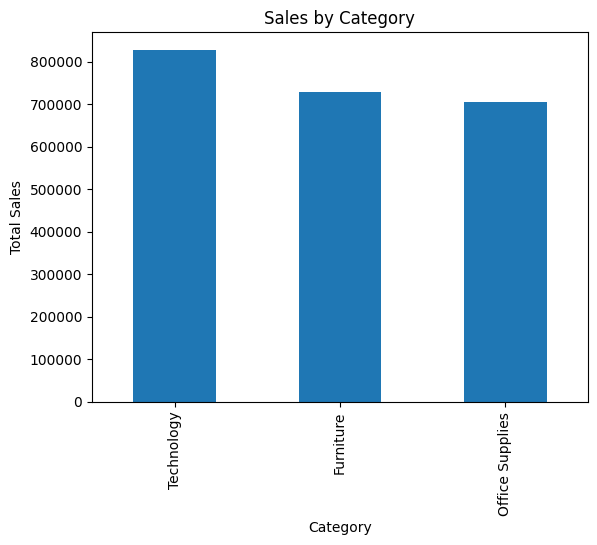

In [10]:
# Plotting our category_sales in bar chart
category_sales. plot (kind = 'bar')

plt. title ("Sales by Category")
plt. xlabel ("Category")
plt. ylabel ("Total Sales")

# Saving the plot in Visuals folder
plt.savefig("../Visuals/sales_by_category.png")

# Viewing the plot
plt. show ()

#### --------------------------------------------------------------------------------------------------------------------------------------------------

# -> Sales on Each Region

In [11]:
# Grouping data by Region column and sum of sales value of Sales column for each region
region_sales = df. groupby ('Region')['Sales']. sum(). sort_values (ascending = False)

# Viewing the result
print (region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


### Here, Groups the data by Region, computes total sales for each region, and sorts them in descending order to display the highest selling region first.

### Insight:
- The highest sales region is West (i.e. 710219.6845)
- The lowest sales region is South (i.e. 389151.4590)
### Observation:
- West region is generating the highest sales.
- This indicates strong market performance in the West region.
- Business can focus on expanding similar strategies in other regions.

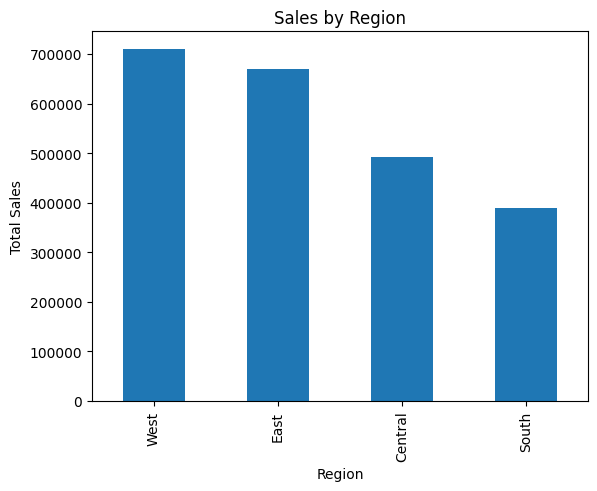

In [12]:
# Plotting our region_sales in bar chart
region_sales. plot (kind = 'bar')

plt. title ("Sales by Region")
plt. xlabel ("Region")
plt. ylabel ("Total Sales")

# Saving the plot in Visuals folder
plt.savefig ("../Visuals/sales_by_region.png")

# Viewing the plot
plt.show()

#### --------------------------------------------------------------------------------------------------------------------------------------------------

# -> Sales on Customer Segment

In [13]:
# Grouping data by Segment column and sum of sales value of Sales column for each segment
segment_sales = df. groupby ('Segment')['Sales']. sum (). sort_values (ascending = False)

# Viewing the result
print (segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


### Here, Groups the data by Segment, computes total sales for each segment, and sorts them in descending order to display the highest selling segment first.

### Insight:
- The highest contributing segment is Consumer (i.e. 1.148061e+06)
- The lowest contributing segment is Home Office (i.e. 4.249822e+05)
### Observation:
- Consumer segment contributes the highest sales.
- This indicates that individual customers are the primary revenue source.
- Business can focus more on consumer-targeted marketing strategies.

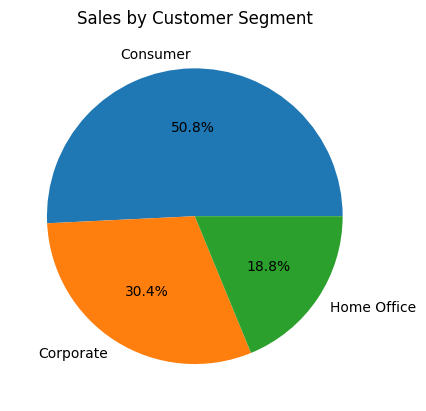

In [14]:
# Plotting our Segment_sales in pie chart
segment_sales. plot (kind = 'pie', autopct = '%1.1f%%')

plt. title ("Sales by Customer Segment")
plt. ylabel ("")  # removing default label

# Saving the plot in Visuals folder
plt.savefig ("../Visuals/sales_by_segment.png")

# Viewing the plot
plt. show ()

#### --------------------------------------------------------------------------------------------------------------------------------------------------

# -> Monthly Sales Trend

In [15]:
# Creating a new column for Month-Year only based on our Order Date column
df ['Order Month'] = df ['Order Date']. dt.to_period ('M')      # means Converting our Order Date column date's into Month + Year format in new column
                                                                #📌 Example:
                                                                  # 2024-01-15 → 2024-01 
                                                                  # 2024-02-10 → 2024-02

# Viewing first 5 rows of Order Date column + Order Month column of dataset
df [['Order Month','Order Date']]. head ()

,Order Month,Order Date
0,2017-11,2017-11-08
1,2017-11,2017-11-08
2,2017-06,2017-06-12
3,2016-10,2016-10-11
4,2016-10,2016-10-11


In [16]:
# Grouping data by Order Month column and sum of sales value of Sales column for each month
monthly_sales = df. groupby ('Order Month')['Sales']. sum ()

# Viewing first 10 rows of the result 
print (monthly_sales. head (10))

Order Month
2015-01    14205.7070
2015-02     4519.8920
2015-03    55205.7970
2015-04    27906.8550
2015-05    23644.3030
2015-06    34322.9356
2015-07    33781.5430
2015-08    27117.5365
2015-09    81623.5268
2015-10    31453.3930
Freq: M, Name: Sales, dtype: float64


### Here, Groups the data by Monthly order, computes total sales for each monthly order.

## NOTE: Don't sort this monthly_sales in any order as we don't want to disturb our year-month order and wanted to see the line graph plotted by it over the period of time.

### Insight:
- Sales show an overall fluctuating trend over time.
- There are noticeable peaks between September to December.
- This indicates higher sales during the end-of-year period, possibly due to seasonal demand or festive shopping.
### Observation:
- Sales are not stable → they fluctuate & Highest sales mostly happens between Sep–Dec.
- During HIGH months, Business can focus on increasing stock (avoid out-of-stock), run promotions & bundles, Focus ads on top products (especially Technology),Improve delivery/logistics.
- During LOW months, Business can focus on boosting weak sales, offer discounts / coupons, run marketing campaigns, introduce new products, target customers (emails, ads), bundle slow products with popular ones.
- Simply, “Sell more when demand is already high” & “Create demand when it is low”.

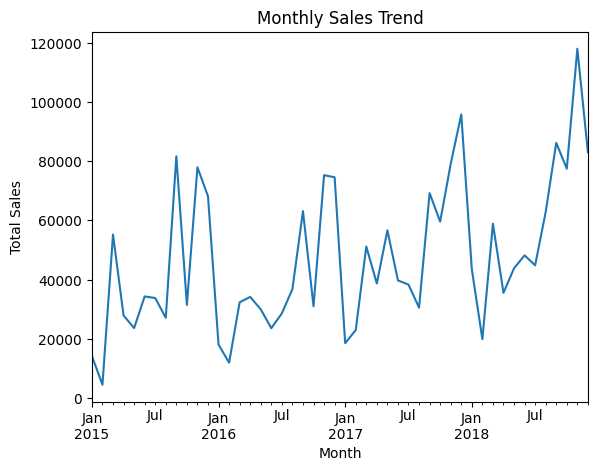

In [17]:
# Plotting our Segment_sales in line chart
monthly_sales. plot ()

plt. title ("Monthly Sales Trend")
plt. xlabel ("Month")
plt. ylabel ("Total Sales")

# Saving the plot in Visuals folder
plt.savefig ("../Visuals/sales_by_month.png")

# Viewing the plot
plt. show ()

#### --------------------------------------------------------------------------------------------------------------------------------------------------

# -> Top 10 Products

In [18]:
# Grouping data by Product Name column and sum of sales value of Sales column for each product
top_products = df. groupby ('Product Name')['Sales']. sum(). sort_values (ascending = False). head (10)    #using desc_sort + head (10) to get top 10

# Viewing the result
print (top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


### Here, Groups the data by Product, computes total sales for each product, and sorts them in descending order along with head() function to display the Top 10 highest selling segment only.

### Insight:
- The top-selling product is Canon imageCLASS 2200 Advanced Copier .
- These products contribute significantly to overall revenue.
- High-value products play a major role in driving total sales.

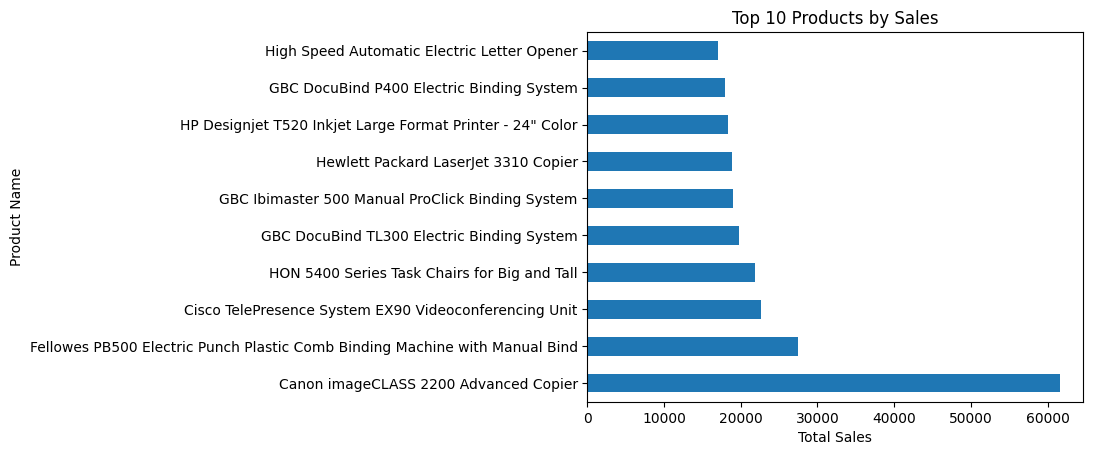

In [20]:
# Plotting our Top 10 product in horizontal bar chart
top_products. plot (kind = 'barh')

plt. title ("Top 10 Products by Sales")
plt. xlabel ("Total Sales")

# Saving the plot in Visuals folder
plt.savefig ("../Visuals/top10_products.png")

# Viewing the plot
plt. show ()

#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------

# Saving Cleaned dataset

In [21]:
# Saving our cleaned dataset as "cleaned_retail_sales_data.csv" in our data folder
df.to_csv("../data/cleaned_retail_sales_data.csv", index=False)

#### --------------------------------------------------------------------------------------------------------------------------------------------------
#### --------------------------------------------------------------------------------------------------------------------------------------------------